In [25]:
import pickle
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from collections import Counter

# 1. Process_pdbs
based on process_pdbs.py in data

In [ ]:
python data/process_pdbs.py 
--data_index_file /Users/hannah/code/rotation1/CoV-Mpro/scripts/atomica_index_file_1319.csv
--out_path /Users/hannah/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_processed.pkl

as a paste-able line

In [ ]:
python data/process_pdbs.py --data_index_file /Users/hannah/code/rotation1/CoV-Mpro/scripts/atomica_index_file_1319.csv --out_path /Users/hannah/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_processed.pkl

In [1]:
import pickle

with open("/Users/hannah/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_processed.pkl", "rb") as f:
    data = pickle.load(f)

len(data)

1319

# 2. Get embeddings
following get_embeddings.py

In [ ]:
python get_embeddings.py 
--model_config ~/code/rotation1/ATOMICA/checkpoints/ATOMICA_checkpoints/prot_interface/atomica_interface_v1.json 
--model_weights ~/code/rotation1/ATOMICA/checkpoints/ATOMICA_checkpoints/prot_interface/atomica_interface_v1.pt 
--data_path ~/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_processed.pkl
--output_path ~/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_embeddings.pkl

as a paste-able line

In [ ]:
python get_embeddings.py --model_config ~/code/rotation1/ATOMICA/checkpoints/ATOMICA_checkpoints/prot_interface/atomica_interface_v1.json --model_weights ~/code/rotation1/ATOMICA/checkpoints/ATOMICA_checkpoints/prot_interface/atomica_interface_v1.pt --data_path ~/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_processed.pkl --output_path ~/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_embeddings.pkl

Going to run this with the other two versions of the model given in hugging face

The output file names
- Fragalysis_SARS_Mpro_embeddings.pkl - model v1
- Fragalysis_SARS_Mpro_embeddings_2.pkl - model v2 
- Fragalysis_SARS_Mpro_embeddings_3.pkl - model v3

In [ ]:
#model v2
python get_embeddings.py --model_config ~/code/rotation1/ATOMICA/checkpoints/ATOMICA_checkpoints/prot_interface/atomica_interface_v2.json --model_weights ~/code/rotation1/ATOMICA/checkpoints/ATOMICA_checkpoints/prot_interface/atomica_interface_v2.pt --data_path ~/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_processed.pkl --output_path ~/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_embeddings_2.pkl

In [ ]:
#model v3
python get_embeddings.py --model_config ~/code/rotation1/ATOMICA/checkpoints/ATOMICA_checkpoints/prot_interface/atomica_interface_v3.json --model_weights ~/code/rotation1/ATOMICA/checkpoints/ATOMICA_checkpoints/prot_interface/atomica_interface_v3.pt --data_path ~/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_processed.pkl --output_path ~/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_embeddings_3.pkl

In [ ]:
with open("/Users/hannah/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

ids = []
graph_embeddings = []

ids = [entry['id'] for entry in embeddings]
graph_embeddings = [entry['graph_embedding'].tolist() for entry in embeddings]


## 2.2 Averaging graph embeddings obtained from the three models

In [4]:
with open("/Users/hannah/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_embeddings.pkl", "rb") as f:
    embeddings_1 = pickle.load(f)
with open("/Users/hannah/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_embeddings_2.pkl", "rb") as f:
    embeddings_2 = pickle.load(f)
with open("/Users/hannah/code/rotation1/ATOMICA/Mpro_analysis/Fragalysis_SARS_Mpro_embeddings_3.pkl", "rb") as f:
    embeddings_3 = pickle.load(f)

ids = []
ids = [entry['id'] for entry in embeddings_1]

g1 = np.array([e['graph_embedding'] for e in embeddings_1])
g2 = np.array([e["graph_embedding"] for e in embeddings_2])
g3 = np.array([e['graph_embedding'] for e in embeddings_3])

mean_graph_embeddings = np.mean(np.stack([g1, g2, g3]), axis=0) #mean across the three models after they are stacked


# 3. UMAP generation

## 3.1 running on just model 1

In [35]:
reducer = UMAP(random_state=42, n_neighbors=15) #reproducible umap
umap_embedding = reducer.fit_transform(graph_embeddings)


/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [14]:
umap_embedding.shape

(1319, 2)

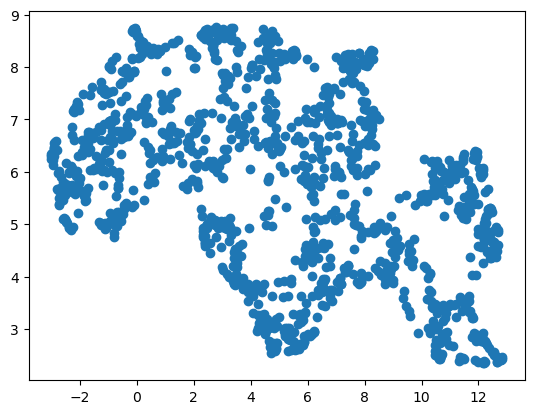

In [36]:
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1])

In [33]:
df = pd.read_csv("/Users/hannah/code/rotation1/CoV-Mpro/scripts/fragalysis_parsed_full_1319.csv")
df["S1_binder"] = df["subsites"].apply(lambda x: "S1" in str(x))

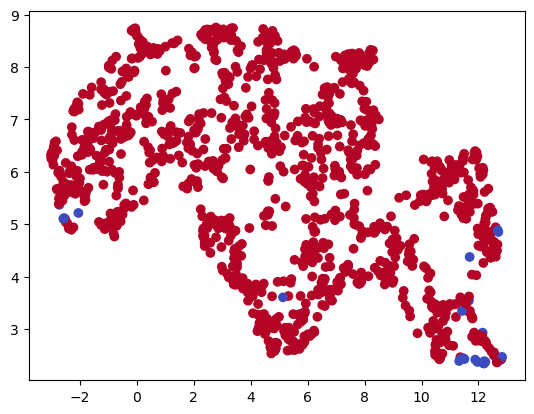

In [37]:
plt.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df["S1_binder"], cmap="coolwarm")

## 3.2 UMAP analysis on all three models
plotting UMAP using plotly as well

In [10]:
#get umap_embeddings

reducer = UMAP(random_state=42, n_components=3) #everything else as default (adjustable parameters = min_dist, n_neighbors)
umap_embedding = reducer.fit_transform(mean_graph_embeddings)

/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [ ]:
df = pd.read_csv("/Users/hannah/code/rotation1/CoV-Mpro/scripts/fragalysis_parsed_full_1319.csv") #labeling information

### 3.2.1 - 2D

In [ ]:

#for plotly plotting and hover labeling
plot_df = pd.DataFrame({
    "x": umap_embedding[:, 0],
    "y": umap_embedding[:, 1],
    "pdb_id": ids,
    "subsites": df["subsites"].astype(str),
    "smiles": df["lig_smiles"]
})

In [22]:
fig = px.scatter(plot_df, x="x", y="y", 
                 hover_data=["pdb_id", "subsites", "smiles"], 
                 title="Fragalysis SARS-CoV-2 Mpro UMAP")

In [8]:
fig.show()

In [9]:
plot_df["is_others"] = plot_df["subsites"].apply(lambda x: "others" in str(x))

fig = px.scatter(
    plot_df,
    x="x", y="y",
    color="is_others",
    hover_data=["pdb_id", "subsites", "smiles"],
    title="Fragalysis SARS-CoV-2 Mpro UMAP"
)

fig.show()

### 3.2.2 3D

In [14]:
plot_df_3d = pd.DataFrame({
    "x": umap_embedding[:, 0],
    "y": umap_embedding[:, 1],
    "z": umap_embedding[:, 2],
    "pdb_id": ids,
    "subsites": df["subsites"].astype(str),
    "smiles": df["lig_smiles"]
})

fig_3d = px.scatter_3d(plot_df_3d, 
                       x="x", y="y", z="z",
                       hover_data=["pdb_id", "subsites", "smiles"], 
                       title="Fragalysis SARS-CoV-2 Mpro UMAP")


fig_3d.update_traces(marker_size=3)

In [17]:
plot_df_3d["is_others"] = plot_df["subsites"].apply(lambda x: "others" in str(x))
fig_3d = px.scatter_3d(plot_df_3d, 
                       x="x", y="y", z="z",
                       color = "is_others",
                       hover_data=["pdb_id", "subsites", "smiles"], 
                       title="Fragalysis SARS-CoV-2 Mpro UMAP")

fig_3d.update_traces(marker_size = 3)

### 3.2.3. colour by subsites

use 2D for now it's easier to work with

In [28]:
all_subsites = [subsites for subsites in plot_df["subsites"]]
Counter(all_subsites).most_common()

[("['S1_prime', 'S1', 'S2', 'S3', 'S4', 'S5']", 753),
 ("['S1_prime', 'S1', 'S2', 'S3', 'S2_prime', 'S4', 'S5']", 308),
 ("['S1_prime', 'S1', 'S2', 'S3', 'S4']", 87),
 ("['S1_prime', 'S1', 'S2', 'S3', 'S6', 'S4', 'S5']", 54),
 ("['S1_prime', 'S1', 'S2', 'S3', 'S2_prime']", 31),
 ("['others']", 29),
 ("['S1_prime', 'S1', 'S2', 'S3', 'S2_prime', 'S4']", 22),
 ("['S1_prime', 'S1', 'S2', 'S3', 'S6', 'S2_prime', 'S4', 'S5']", 13),
 ("['S3', 'S1_prime', 'S2_prime', 'S1']", 7),
 ("['S1_prime', 'S2_prime', 'S1', 'S2']", 4),
 ("['S3', 'S1_prime', 'S1', 'S4']", 3),
 ("['S1_prime', 'S1', 'S2', 'S3', 'S3_prime', 'S4_prime', 'S2_prime']", 2),
 ("['S1_prime', 'S1', 'S3', 'S2_prime', 'S4']", 1),
 ("['S1_prime', 'S1', 'S3_prime', 'S4_prime', 'S2_prime']", 1),
 ("['S6', 'S2', 'S4', 'S5']", 1),
 ("['S1', 'S2', 'S3', 'S6', 'S4', 'S5']", 1),
 ("['S1_prime', 'S2_prime', 'S2']", 1),
 ("['S1_prime', 'S2', 'S3', 'S4', 'S5']", 1)]

In [29]:
plot_df["reaches_S2_prime"] = plot_df["subsites"].apply(lambda x: "S2_prime" in str(x))
plot_df["reaches_S6"] = plot_df["subsites"].apply(lambda x: "S6" in str(x))
plot_df["reaches_S2_prime_only"] = plot_df["subsites"].apply(
    lambda x: "S2_prime" in str(x) and "S6" not in str(x)
)

In [34]:
def classify_binder(subsites):
    s = str(subsites)
    if "others" in s:
        return "Others"
    elif "S6" in s and "S2_prime" in s:
        return "S6 + S2_prime"
    elif "S6" in s:
        return "S6"
    elif "S2_prime" in s:
        return "S2_prime"
    else:
        return "Standard (S1_prime-S5)"

plot_df["binding_class"] = plot_df["subsites"].apply(classify_binder)

In [37]:
fig = px.scatter(
    plot_df,
    x="x", y="y",
    color="binding_class",
    hover_data=["pdb_id", "subsites", "smiles"],
    title="Fragalysis SARS-CoV-2 Mpro UMAP",
    color_discrete_map={
        "Standard (S1_prime-S5)": "lightgrey",
        "S2_prime": "royalblue",
        "S6": "tomato",
        "S6 + S2_prime": "purple",
        "Others": "gold"
    }
)

fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.show()

#### 3.2.3.1 trying parameters of UMAP

In [52]:
n_neighbors_list = [5, 15, 30, 50, 100, 200]
results = {}

for n in n_neighbors_list:
    reducer = UMAP(n_neighbors=n, min_dist=0.1, random_state=42)
    emb = reducer.fit_transform(mean_graph_embeddings)
    results[n] = emb

/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/hannah/miniforge3/envs/atomicaenv/lib/pytho

In [53]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=3, cols=2, 
                    subplot_titles=[f"n_neighbors={n}" for n in n_neighbors_list])

positions = [(1,1), (1,2), (2,1), (2,2), (3,1), (3,2)]

for (row, col), n in zip(positions, n_neighbors_list):
    emb = results[n]
    for binding_class, color in {
        "Standard (S1_prime-S5)": "lightgrey",
        "S2_prime": "royalblue",
        "S6": "tomato",
        "S6 + S2_prime": "purple",
        "Others": "gold"
    }.items():
        mask = plot_df["binding_class"] == binding_class
        fig.add_trace(go.Scatter(
            x=emb[mask, 0], y=emb[mask, 1],
            mode="markers",
            name=binding_class,
            legendgroup=binding_class,
            showlegend=(row==1 and col==1),  # only show legend once
            marker=dict(size=3, opacity=0.7, color=color),
            text=plot_df["pdb_id"][mask]
        ), row=row, col=col)

fig.show()

### 3.2.4 Adjusted UMAP
- parameters adjusted (n_neighbors = 30, min_dist = 0.1)

In [55]:
#going for n_neighbors = 30, min_dist = 0.1
reducer = UMAP(random_state=42, n_neighbors=30)
umap_embedding = reducer.fit_transform(mean_graph_embeddings)

/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [56]:
plot_df = pd.DataFrame({
    "x": umap_embedding[:, 0],
    "y": umap_embedding[:, 1],
    "pdb_id": ids,
    "subsites": df["subsites"].astype(str),
    "smiles": df["lig_smiles"]
})

plot_df["reaches_S2_prime"] = plot_df["subsites"].apply(lambda x: "S2_prime" in str(x))
plot_df["reaches_S6"] = plot_df["subsites"].apply(lambda x: "S6" in str(x))
plot_df["reaches_S2_prime_only"] = plot_df["subsites"].apply(
    lambda x: "S2_prime" in str(x) and "S6" not in str(x))

def classify_binder(subsites):
    s = str(subsites)
    if "others" in s:
        return "Others"
    elif "S6" in s and "S2_prime" in s:
        return "S6 + S2_prime"
    elif "S6" in s:
        return "S6"
    elif "S2_prime" in s:
        return "S2_prime"
    else:
        return "Standard (S1_prime-S5)"

plot_df["binding_class"] = plot_df["subsites"].apply(classify_binder)

In [60]:
fig = px.scatter(
    plot_df,
    x="x", y="y",
    color="binding_class",
    hover_data=["pdb_id", "subsites", "smiles"],
    title="Fragalysis SARS-CoV-2 Mpro UMAP",
    color_discrete_map={
        "Standard (S1_prime-S5)": "grey",
        "S2_prime": "royalblue",
        "S6": "tomato",
        "S6 + S2_prime": "purple",
        "Others": "green"
    }
)

fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.show()

# 4.Playing

In [62]:
from sklearn.cluster import HDBSCAN

clusterer = HDBSCAN(min_cluster_size=30)
plot_df["cluster"] = clusterer.fit_predict(umap_embedding)
# -1 means noise/unassigned

/Users/hannah/miniforge3/envs/atomicaenv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning:

The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.



In [63]:
from rdkit import Chem
from rdkit.Chem import Descriptors

plot_df["mol_weight"] = plot_df["smiles"].apply(
    lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)) if pd.notna(x) else None
)

# 2. does mol weight differ between left and right?
plot_df.groupby("cluster")["mol_weight"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
-1,238.0,426.201887,110.087043,150.181,344.7735,422.852,521.03575,665.101
0,116.0,300.264034,57.131080,147.181,278.3715,286.536,336.55050,476.964
1,85.0,236.131482,58.886003,73.119,209.2490,238.331,277.32400,375.475
2,494.0,352.749130,71.781344,203.245,298.3560,340.768,389.64575,597.104
3,41.0,490.013829,81.973928,258.296,439.8990,529.000,541.05500,597.104
4,345.0,495.330278,79.986879,229.239,456.9550,505.018,548.04300,848.357


In [64]:
plot_df["cluster"] = plot_df["cluster"].astype(str)  # convert to string so plotly treats it as categorical

fig = px.scatter(
    plot_df,
    x="x", y="y",
    color="cluster",
    hover_data=["pdb_id", "subsites", "smiles", "mol_weight"],
    title="Fragalysis SARS-CoV-2 Mpro UMAP - HDBSCAN clusters"
)

fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.show()